In [1]:
!pip install arch --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 49.9 MB/s eta 0:00:00


In [2]:
data = yf.download("^FTSE", start='2005-1-1', end='2025-1-1', auto_adjust=True) #Downloading 15 years of data from the FTSE 100
prices = data["Close"].dropna()

[*********************100%***********************]  1 of 1 completed


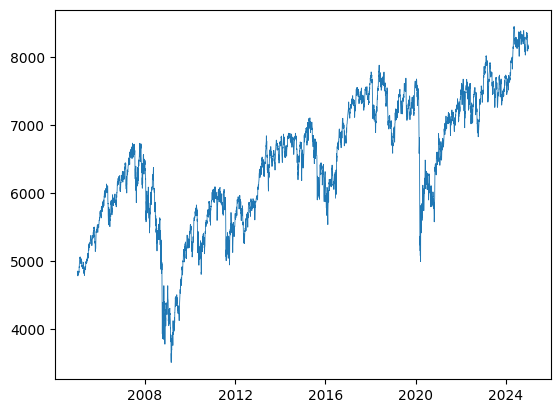

In [3]:
plt.plot(prices, linewidth = 0.6)

In [4]:
log_returns = np.log(prices/prices.shift(1)).dropna()
log_returns = log_returns.squeeze()

realised_vol = log_returns.rolling(window=21).std() * np.sqrt(252)
realised_vol = realised_vol.squeeze()

print(f"log_returns shape: {log_returns.shape}")
print(f"realised_vol shape: {realised_vol.shape}")

log_returns shape: (5049,)
realised_vol shape: (5049,)


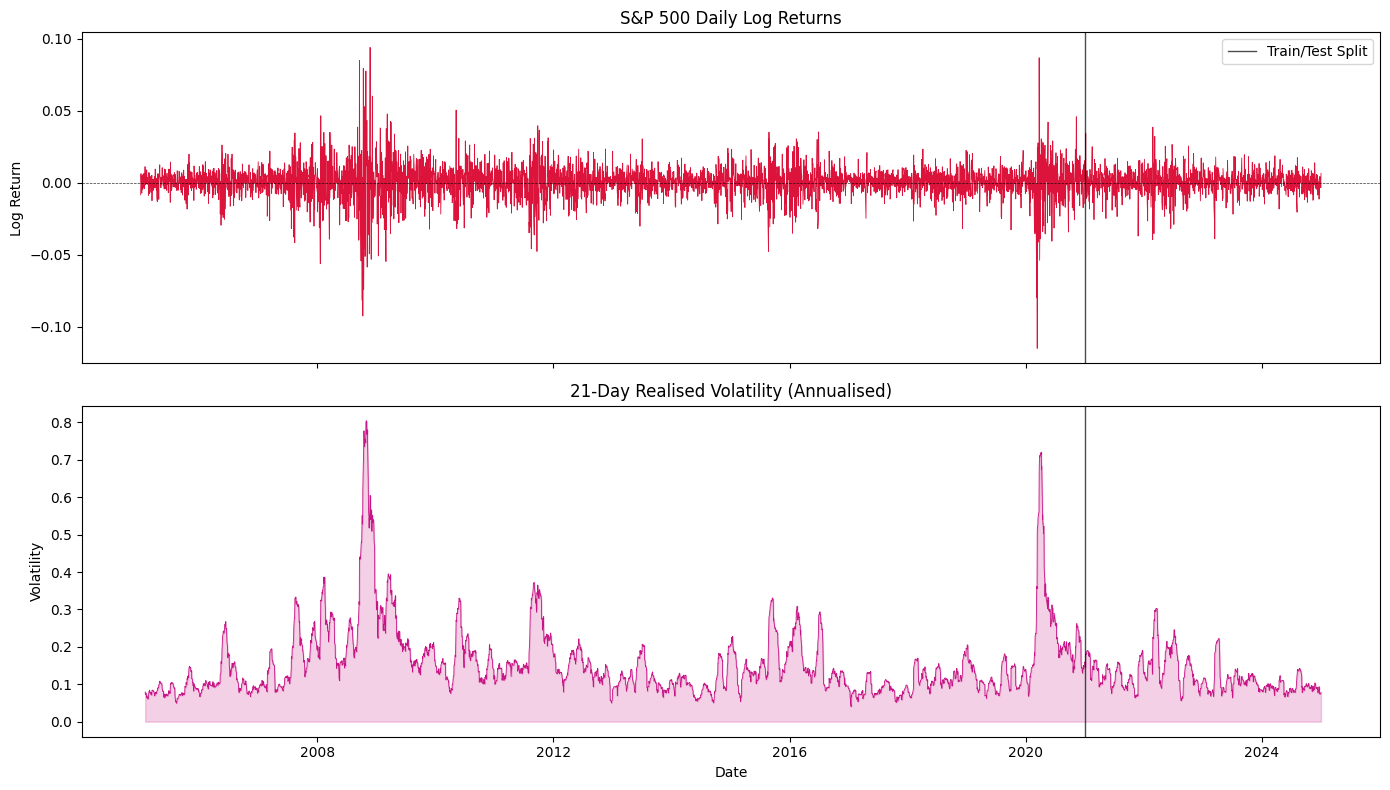

In [5]:
train_size = int(len(realised_vol) * 0.8)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

ax1.plot(log_returns.index, log_returns.values, linewidth=0.6, color='crimson')
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.8)
ax1.set_title('S&P 500 Daily Log Returns')
ax1.set_ylabel('Log Return')

ax2.fill_between(realised_vol.index, realised_vol.values, alpha=0.2, color='mediumvioletred')
ax2.plot(realised_vol.index, realised_vol.values, linewidth=0.6, color='mediumvioletred')
ax2.set_title('21-Day Realised Volatility (Annualised)')
ax2.set_ylabel('Volatility')
ax2.set_xlabel('Date')

# Mark the train/test split
split_date = realised_vol.index[train_size]
ax1.axvline(split_date, color='black', linewidth=1, alpha=0.7, label='Train/Test Split')
ax2.axvline(split_date, color='black', linewidth=1, alpha=0.7)
ax1.legend()

plt.tight_layout()
plt.savefig('data_overview_sp500.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
returns_for_garch = log_returns * 100

vol_split_idx = int(len(realised_vol) * 0.8)
vol_train = realised_vol.iloc[:vol_split_idx].dropna()
vol_test  = realised_vol.iloc[vol_split_idx:].dropna()

ret_split_idx = int(len(returns_for_garch) * 0.8)
ret_train = returns_for_garch.iloc[:ret_split_idx].dropna()
ret_test  = returns_for_garch.iloc[ret_split_idx:].dropna()

In [7]:
model = arch_model(
    ret_train,
    vol='Garch',
    p=1,
    q=1,
    dist='normal'
)

garch_fit = model.fit(disp='off')

print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^FTSE   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5459.03
Distribution:                  Normal   AIC:                           10926.1
Method:            Maximum Likelihood   BIC:                           10951.3
                                        No. Observations:                 4039
Date:                Wed, Jun 10 2026   Df Residuals:                     4038
Time:                        16:10:01   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0405  1.296e-02      3.124  1.782e-03 [1.

In [8]:
garch_forecasts = []

n_test = len(ret_test)

for i in range(n_test):
  ret_available = returns_for_garch.iloc[:ret_split_idx+i]

  roll_model = arch_model(ret_available, vol='Garch', p=1, q=1, dist='normal')
  roll_fit = roll_model.fit(disp='off', show_warning=False)

  forecast = roll_fit.forecast(horizon=1)
  next_var = forecast.variance.values[-1,0]
  next_vol = np.sqrt(next_var)/100 * np.sqrt(252)

  garch_forecasts.append(next_vol)

garch_forecasts = pd.Series(garch_forecasts, index=vol_test.index)

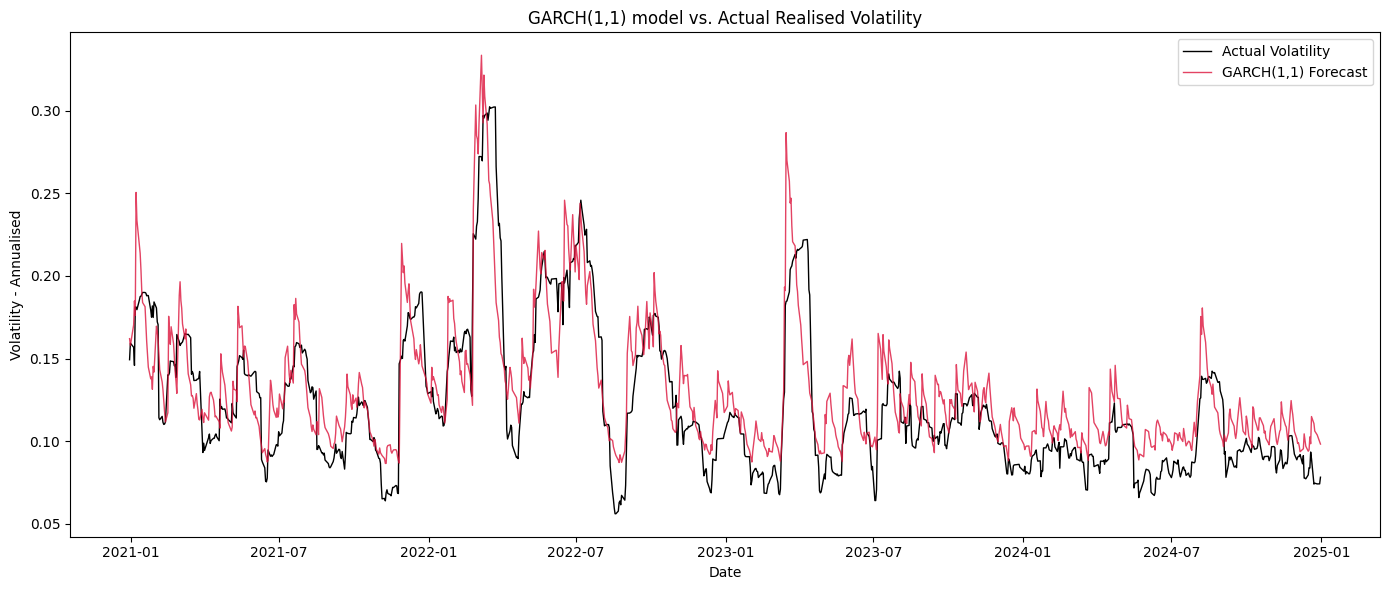

In [20]:
plt.figure(figsize=(14,6))

plt.plot(vol_test.index, vol_test.values, color = 'black', linewidth=1, label='Actual Volatility')
plt.plot(garch_forecasts.index, garch_forecasts.values, color = 'crimson', linewidth=1, alpha=0.8, label='GARCH(1,1) Forecast')

plt.title('GARCH(1,1) model vs. Actual Realised Volatility')
plt.ylabel('Volatility - Annualised')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
rmse_garch = np.sqrt(mean_squared_error(vol_test, garch_forecasts))
mae_garch  = mean_absolute_error(vol_test, garch_forecasts)

print(f"GARCH RMSE: {rmse_garch:.4f}")
print(f"GARCH MAE:  {mae_garch:.4f}")

GARCH RMSE: 0.0241
GARCH MAE:  0.0193


# Prepping for my LSTM

In [11]:
scaler = MinMaxScaler()

vol_train_scaled = scaler.fit_transform(vol_train.values.reshape(-1,1))
vol_test_scaled = scaler.transform(vol_test.values.reshape(-1,1))

print(f"Training data range after scaling: {vol_train_scaled.min():.3f} to {vol_train_scaled.max():.3f}")
print(f"Test data range after scaling:     {vol_test_scaled.min():.3f} to {vol_test_scaled.max():.3f}")

Training data range after scaling: 0.000 to 1.000
Test data range after scaling:     0.021 to 0.343


In [12]:
WINDOW_SIZE = 20

def Sequence_Maker(data, windowsize):
  X = []
  y = []
  for i in range(len(data)-windowsize):
    X.append(data[i:i+windowsize])
    y.append(data[i+windowsize])

  return np.array(X), np.array(y)

X_train, y_train = Sequence_Maker(vol_train_scaled, WINDOW_SIZE)
X_test, y_test = Sequence_Maker(vol_test_scaled, WINDOW_SIZE)

In [13]:
X_train_t = torch.FloatTensor(X_train).to('cuda')
y_train_t = torch.FloatTensor(y_train).to('cuda')
X_test_t = torch.FloatTensor(X_test).to('cuda')
y_test_t = torch.FloatTensor(y_test).to('cuda')

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = False)

# Making the LSTM

In [14]:
class VolatilityLSTM(nn.Module):
  def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
    super(VolatilityLSTM, self).__init__()
    self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=dropout
    )
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    lstm_out, _ = self.lstm(x)
    last_output = lstm_out[:,-1,:]
    prediction = self.fc(last_output)
    return prediction

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_lstm = VolatilityLSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)

In [15]:
criterion = nn.MSELoss()
optimiser=torch.optim.Adam(model_lstm.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=10, factor=0.5)

EPOCHS = 100

train_losses = []

for epoch in range(EPOCHS):
  model_lstm.train()
  epoch_loss=0

  for X_batch, y_batch in train_loader:
    optimiser.zero_grad()
    predictions=model_lstm(X_batch)
    loss=criterion(predictions, y_batch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
    optimiser.step()
    epoch_loss += loss.item()

  avg_loss = epoch_loss/len(train_loader)
  train_losses.append(avg_loss)

  scheduler.step(avg_loss)

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.6f}")

print("\nTraining complete.")

Epoch  10/100 | Loss: 0.000754
Epoch  20/100 | Loss: 0.000479
Epoch  30/100 | Loss: 0.000372
Epoch  40/100 | Loss: 0.000357
Epoch  50/100 | Loss: 0.000326
Epoch  60/100 | Loss: 0.000358
Epoch  70/100 | Loss: 0.000309
Epoch  80/100 | Loss: 0.000291
Epoch  90/100 | Loss: 0.000286
Epoch 100/100 | Loss: 0.000324

Training complete.


In [16]:
model_lstm.eval()
lstm_forecasts = []

with torch.no_grad():
  for i in range(len(X_test_t)):
    x=X_test_t[i].unsqueeze(0)
    pred=model_lstm(x)
    lstm_forecasts.append(pred.item())

lstm_forecasts = np.array(lstm_forecasts).reshape(-1,1)
lstm_forecasts = scaler.inverse_transform(lstm_forecasts).flatten()

lstm_forecast_index = vol_test.index[WINDOW_SIZE:]
lstm_forecasts_series = pd.Series(lstm_forecasts, index=lstm_forecast_index)

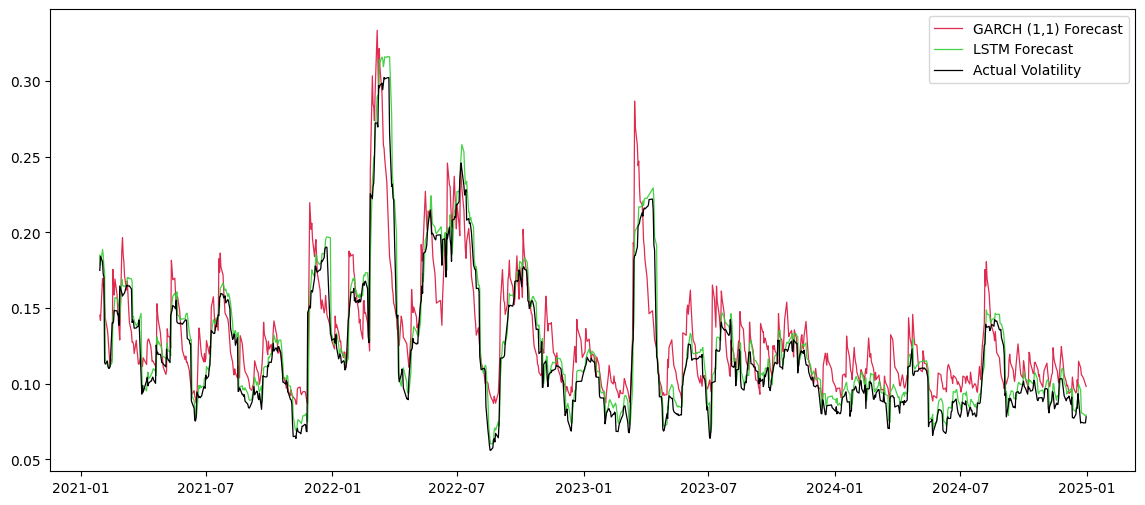

In [26]:
common_index = lstm_forecasts_series.index
actual_aligned = vol_test.loc[common_index]
garch_aligned  = garch_forecasts.loc[common_index]

plt.figure(figsize=(14,6))

plt.plot(common_index, garch_aligned.values, label='GARCH (1,1) Forecast', color='crimson', linewidth=0.9, alpha=0.9)
plt.plot(common_index, lstm_forecasts_series, label='LSTM Forecast', color='limegreen', linewidth=0.9, alpha=0.9)
plt.plot(common_index, actual_aligned.values, label='Actual Volatility', color = 'Black', linewidth=0.9)
plt.legend()


In [18]:
rmse_lstm = np.sqrt(mean_squared_error(actual_aligned, lstm_forecasts_series))
mae_lstm  = mean_absolute_error(actual_aligned, lstm_forecasts_series)

print(f"LSTM RMSE: {rmse_lstm:.4f}")
print(f"LSTM MAE:  {mae_lstm:.4f}")

rmse_garch = np.sqrt(mean_squared_error(actual_aligned, garch_aligned))
mae_garch  = mean_absolute_error(actual_aligned, garch_aligned)

print(f"GARCH RMSE: {rmse_garch:.4f}")
print(f"GARCH MAE:  {mae_garch:.4f}")

LSTM RMSE: 0.0107
LSTM MAE:  0.0074
GARCH RMSE: 0.0239
GARCH MAE:  0.0192
